#### TYPEDICT:::

In [1]:
person = {"name":"surya","age":28,"company":"newgen software"}

In [2]:
person['maritalStatus']='Not known'
person['education']=12345
person['designation']='T34m L34434der'


In [3]:
person

{'name': 'surya',
 'age': 28,
 'company': 'newgen software',
 'maritalStatus': 'Not known',
 'education': 12345,
 'designation': 'T34m L34434der'}

From above, we can see that, there are no restrictions for data to be inserted inside a dictionary. Now **Type Dict** doesn't allow this. It is like setting the request tags of an API with a particular type. This will restrict the data to be inserted inside a dictionary to a particular type. For example, if we set the type of a dictionary to `int`, then only integer values can be inserted into that dictionary. Any attempt to insert a value of a different type will result in an error.

State will be maintanied in a Type Dict, and it will only have two keys, i,e. "Question" and "Answer" of type `str`. This means that the dictionary can only hold string values for both the "Question" and "Answer" keys. If you try to insert a value of a different type, such as an integer or a list, it will raise a type error.

In [4]:
from typing import TypedDict

In [5]:
class State(TypedDict):
    question:str
    answer:str

In [6]:
State(question=12213,answer=213)

{'question': 12213, 'answer': 213}

### Build a basic flow in LangGraph

Start -> Analyse -> respond -> End

In [ ]:
%pip install langgraph

In [8]:
from dotenv import load_dotenv
import os
from openai import OpenAI
from langgraph.graph import StateGraph, START,END
from IPython.display import display,Image

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [9]:
load_dotenv()
grokAPIKey = os.getenv("GroqAPIKey")


In [10]:
client = OpenAI(api_key=grokAPIKey,base_url="https://api.groq.com/openai/v1")

In [59]:
def speakWithLLM(prompt,systemPrompt="You are an useful assistant"):
    message = [{
        "role":"system",
        "content":systemPrompt
    },
    {
        "role":"user",  
        "content":prompt

    }]

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=message,
        temperature=0.2
    )

    return response.choices[0].message.content

In [12]:
print(speakWithLLM("Which model are you using?"))

I'm using a combination of natural language processing (NLP) and machine learning algorithms to understand and respond to your questions. My primary model is based on the transformer architecture, which is a type of neural network designed specifically for NLP tasks.

More specifically, I'm using a variant of the BERT (Bidirectional Encoder Representations from Transformers) model, which was developed by Google. BERT is a pre-trained language model that has been trained on a large corpus of text data, allowing it to learn the patterns and relationships of language.

My model is fine-tuned on a wide range of tasks, including but not limited to:

* Conversational dialogue
* Question answering
* Text classification
* Sentiment analysis
* Language translation

This allows me to understand and respond to a wide range of questions and topics, from simple queries to more complex and open-ended discussions.


In [13]:
print(speakWithLLM("One beautyful place of France?"))

One of the most beautiful places in France is the village of Giverny, located in the Normandy region. It's famous for being the home of Claude Monet, the founder of Impressionism, and the inspiration for many of his paintings.

Giverny is a charming village surrounded by lush greenery, with beautiful gardens, water lilies, and a stunning Japanese bridge. The village is also home to Monet's former residence, which is now a museum showcasing his artwork and personal belongings.

The most iconic attraction in Giverny is Monet's Garden, which features a stunning array of flowers, trees, and a beautiful pond filled with water lilies. The garden is a must-visit for anyone who loves nature, art, and beauty.

Visitors can also explore the village's narrow streets, visit the local church, and enjoy the region's delicious cuisine, including fresh seafood and traditional Norman dishes.

Giverny is a perfect destination for those who want to experience the beauty of French countryside, art, and hi

## A simple Graph model

### State class

In [ ]:
class InputState:
    name:str
    greeting:str
    output:str

### Creating Node

In [53]:
## NOde is nothing but a python function

def greeting(state):    
    '''Creating a greeting node with name'''
    name = state['name']
    #age = state['age']
    #greeting = f"Hello {name}, Welcome to simple Langgraph build. This course is {age} old."
    greeting = f"Hello {name}, Welcome to simple Langgraph build."
    return {'greeting':greeting}

def makeUppercase(state):
    result = state['greeting'].upper()
    print(f"result:  {result}")
    #return{"greeting":result,"age":state["age"]}
    return{"greeting":result}




### Graph Creation - Nodes

In [54]:
graph = StateGraph(InputState)

graph.add_node("greeting",greeting)
graph.add_node("makeUppercase",makeUppercase)

### Graph creation - Edges

In [55]:
graph.add_edge(START,"greeting")
graph.add_edge("greeting","makeUppercase")
graph.add_edge("makeUppercase",END)


In [56]:
simpleGraph = graph.compile()

print("Graph is built")

Graph is built


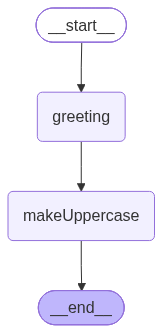

In [25]:
display(Image(simpleGraph.get_graph().draw_mermaid_png()))

In [ ]:
simpleGraph.invoke({"name":"Veena"})

result:  HELLO VEENA, WELCOME TO SIMPLE LANGGRAPH BUILD


{'name': 'Veena', 'greeting': 'HELLO VEENA, WELCOME TO SIMPLE LANGGRAPH BUILD'}

- From above, we haven't used output variable from the "InputState", so in the result we didn't get that output variable. 

In [46]:
simpleGraph.invoke({"name":"Veena","age":23})

KeyError: 'age'

- Why are we egtting this error? Because we haven't defined the "age" variable in the "InputState" node. So, when we try to access the a variable that is not present in State, we get an error.
- If we do not access the variable, Langghraph will ignore it silently.

In [57]:
simpleGraph.invoke({"name":"Veena","age":23})

result:  HELLO VEENA, WELCOME TO SIMPLE LANGGRAPH BUILD.


{'name': 'Veena',
 'greeting': 'HELLO VEENA, WELCOME TO SIMPLE LANGGRAPH BUILD.'}

- See now we didn't get any error, because, we have commented tghe lines, where we accessing "age" in our nodes. So, Langgraph will ignore it silently, vwn if we send something in out input.

### LangGraph Basic Flow
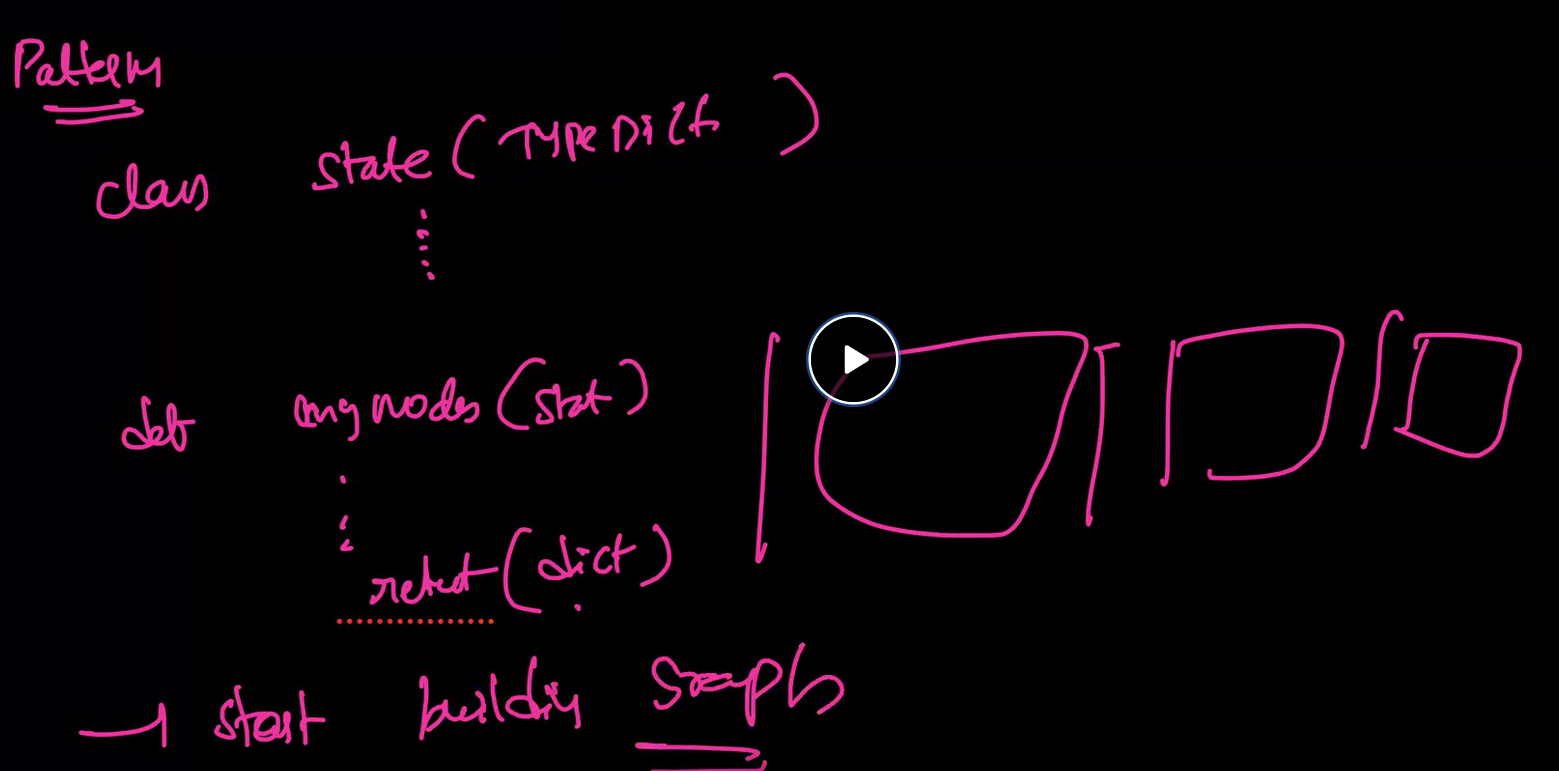

### Involving LLM

In [60]:
class LLMState(TypedDict):
    question: str
    topic: str
    answer: str



### Nodes definition

In [61]:
def analyse(state):
    question = state["question"]
    topic = speakWithLLM(prompt=f"What is the main topic of the question: {question}. Reply with only 1 word.",systemPrompt="You are an usefull assistant, which find the core topic of the question given and reply in only one word.")

    print(f"Topic of the Question: {question}::: {topic}")
    return {"topic":topic}

def respond(state):
    question = state["question"]
    answer = speakWithLLM(prompt=f"Answer in 2-3 lines. {question}",systemPrompt="You are an usefull assistant, which answers the question in 2-3 lines.")
    print(f"Answer to the Question: {question}::: {answer}")
    return {"answer":answer}

### Graph creation - with Nodes

In [64]:
qaAssistantGraph = StateGraph(LLMState)

qaAssistantGraph.add_node("analyse",analyse)
qaAssistantGraph.add_node("respond",respond)

### Edges

In [65]:
qaAssistantGraph.add_edge(START,"analyse")
qaAssistantGraph.add_edge("analyse","respond")
qaAssistantGraph.add_edge("respond",END)

### Compiling the Graph

In [66]:
qaAssistant = qaAssistantGraph.compile()

### Testing the Graph

In [69]:
qaAssistant.invoke({"question":"What is the most delicious indian food?"})

Topic of the Question: What is the most delicious indian food?::: Food
Answer to the Question: What is the most delicious indian food?::: Butter Chicken and Biryani are popular choices. 
Tandoori Chicken is also a favorite among many. 
These dishes are known for their rich flavors.


{'question': 'What is the most delicious indian food?',
 'topic': 'Food',
 'answer': 'Butter Chicken and Biryani are popular choices. \nTandoori Chicken is also a favorite among many. \nThese dishes are known for their rich flavors.'}

### Conditional Graph

### Input State

In [73]:
class ConditionalLLMState(TypedDict):
    question: str
    intent: str
    answer: str
    context: str



### Defining Nodes

In [78]:
def analyseIntent(state):
    question = state["question"]
    intent = speakWithLLM(prompt=f"There are nly 3 categories: Billing, HR, General. What is the category of the question: {question}. Reply with only 1 word.",systemPrompt="You are an usefull assistant, which classifies the question into HR, Billing or General and reply with the category name.")
    if intent not in ["Billing","HR","General"]:
        intent = "General"

    #print(f"Topic of the Question: {question}::: {topic}")
    return {"intent":intent}

def billingAssistant(state):
    question = state["question"]
    answer = speakWithLLM(prompt=f"Answer in 2-3 lines. {question}",systemPrompt="You are an usefull assistant, which answers about subscriptions, offers, PO's etc, everything related to billing in 2-3 lines.")
    #print(f"Answer to the Question: {question}::: {answer}")
    return {"answer":answer,"context":"Billing Documents"}

def hrAssistant(state):
    question = state["question"]
    answer = speakWithLLM(prompt=f"Answer in 2-3 lines. {question}",systemPrompt="You are an usefull assistant, which answers about WFH, Insurance etc, everything related to HR in 2-3 lines.")
    #print(f"Answer to the Question: {question}::: {answer}")
    return {"answer":answer,"context":"HR Documents"}

def generalAssistant(state):
    question = state["question"]
    answer = speakWithLLM(prompt=f"Answer in 2-3 lines. {question}",systemPrompt="You are an usefull assistant, which answers the question in 2-3 lines.")
    #print(f"Answer to the Question: {question}::: {answer}")
    return {"answer":answer,"context":"General Documents"}

def routeByIntent(state):
    intent = state["intent"]

    if intent == "Billing":
        return "Billing Agent"
    elif intent == "HR":
        return "HR Agent"
    else:
        return "General Agent"

### Graph creation - with Nodes

In [79]:
conditionalG = StateGraph(ConditionalLLMState)

conditionalG.add_node("analyseIntent",analyseIntent)
conditionalG.add_node("billingAssistant",billingAssistant)
conditionalG.add_node("hrAssistant",hrAssistant)
conditionalG.add_node("generalAssistant",generalAssistant)


### Edges

In [80]:
conditionalG.add_edge(START,"analyseIntent")

#Adding conditional edges

conditionalG.add_conditional_edges(
    "analyseIntent",
    routeByIntent,
    {
        "HR Agent":"hrAssistant",
        "General Agent":"generalAssistant",
        "Billing Agent":"billingAssistant"
    }
)

conditionalG.add_edge("hrAssistant",END)
conditionalG.add_edge("billingAssistant",END)
conditionalG.add_edge("generalAssistant",END)

### Compiling the Graph

In [81]:
companyAsst = conditionalG.compile()

### Testing the Graph

In [84]:
companyAsst.invoke({"question":"When is my hike cycle?"})

{'question': 'When is my hike cycle?',
 'intent': 'HR',
 'answer': "Your hike cycle typically occurs after completing a performance review or at the end of a fixed period, usually 6-12 months. Check your company's policy or consult with HR for the exact timeline. This may vary based on company norms.",
 'context': 'HR Documents'}

In [85]:
companyAsst.invoke({"question":"How to reimburse the WFH setup"})

{'question': 'How to reimburse the WFH setup',
 'intent': 'Billing',
 'answer': 'To reimburse the WFH setup, submit a request with receipts to the finance team. They will process the reimbursement as per company policy. Please check with your HR for the exact procedure.',
 'context': 'Billing Documents'}

In [86]:
companyAsst.invoke({"question":"What is Agentic AI?"})

{'question': 'What is Agentic AI?',
 'intent': 'General',
 'answer': 'Agentic AI refers to artificial intelligence systems that can act autonomously. These systems have their own goals and can make decisions to achieve them. They operate independently, like agents, in their environment.',
 'context': 'General Documents'}